In [3]:
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [4]:
def set_async_factor(k) -> (float, float):
        if k == 0:
            k_b = k_a = 0.5
        dirCoef = round(abs(k), 2)
        resideCoef = round(1 - dirCoef, 2)
        if k < 0:
            k_b = resideCoef
            k_a = dirCoef
        if k > 0:
            k_b = dirCoef
            k_a = resideCoef
        return (k_a, k_b)

def calc_range(p_range: float, pn: float, k: float):
    k_a, k_b = set_async_factor(k)
    pb = pn + p_range * k_b
    pa = pn - p_range * k_a
    return (pa, pb)

In [15]:
class Exchange:
    price_data: pd.DataFrame
    step: int

    def __init__(self, data_in):
        self.price_data = data_in
        self._total_iterations = len(data_in)
        self.reset_step()

    def get_step(self):
        row = self.price_data.iloc[self.step]
        return (row['open_time'], row['close'])

    def reset_step(self):
        self.step = 0

    def go_step(self):
        self.step +=1
        # if self.is_not_finish:
        #     time, price = self.get_step()
        #     self.pool.step(price)
        return self.step

    @property
    def is_not_finish(self):
        return self.step < self.total_iterations

    @property
    def total_iterations(self):
        return self._total_iterations    

In [89]:
class Pool:
    def __init__(self):
        self.is_open = False
        
    def open(self, price, capital, pa, pb):
        self.pn = price
        self.pa = pa
        self.pb = pb
        self.capital = capital
        self.Lq = self.calculate_liquidity()
        self.is_open = True

    def calculate_liquidity(self):
        price = self.pn
        if self.pn <= self.pa or self.pn >= self.pb:
            price = (self.pa + self.pb) / 2
    
        sqrt_pn = np.sqrt(price)
        sqrt_pa = np.sqrt(self.pa)
        sqrt_pb = np.sqrt(self.pb)
        
        term1 = sqrt_pn - sqrt_pa
        term2 = price * (1/sqrt_pn - 1/sqrt_pb)
        if (term1 + term2) == 0:
            return 0.0
        
        return self.capital / (term1 + term2)
        
        # if verbose_logging and abs(calculate_pool_value(pn_price, pa_price, pb_price, l) - capital_amount) > capital_amount * 0.01:
        #     print(f"  Внимание: разница в расчетах. Capital=${capital_amount:.2f}, Pool Value at Pn=${calculate_pool_value(pn_price, pa_price, pb_price, l):.2f}")
        # return l

    def get_size(self, price) -> float:
        """
        price - текущая цена
        """
        if self.Lq <= 0:
            return 0.0
        sqrt_price = np.sqrt(price)
        sqrt_pa = np.sqrt(self.pa)
        sqrt_pb = np.sqrt(self.pb)
        if price <= self.pa:
            pool_eth = self.Lq * (1/sqrt_pa - 1/sqrt_pb)
            return pool_eth * price
        elif price >= self.pb:
            return self.Lq * (sqrt_pb - sqrt_pa)
        else:
            pool_usdc = self.Lq * (sqrt_price - sqrt_pa)
            pool_eth = self.Lq * (1/sqrt_price - 1/sqrt_pb)
            return pool_usdc + pool_eth * price
        
    def close(self, price) -> float:
        result = self.get_size(price)
        self.is_open = False
        return result
        

In [58]:
class Short:
    def __init__(self):
        self.is_open = False
        
    def open(self, price, capital):
        self.pn = price
        self.capital = capital
        self.is_open = True

    def get_size(self, price) -> float:
        if self.is_open :
            purchase = self.pn * self.capital
            return purchase / price if price != 0.0 else 0.0
        return None
    
    def close(self, price) -> float:
        result = self.get_size(price)
        self.is_open = False
        return result

In [7]:
# Загрузка excel файла
data_csv = pd.read_csv("in_datas/eth_2025_full.csv")

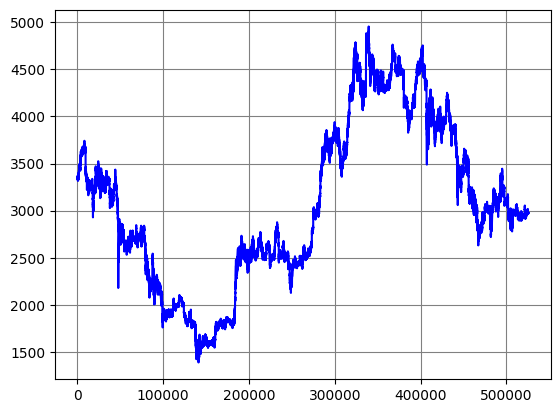

In [36]:
plt.plot(data_csv.index, data_csv['close'], color="blue", label="Цена")
plt.grid(True, color="gray")
plt.show()

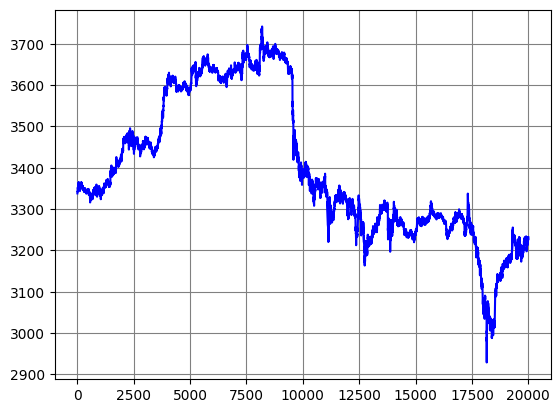

In [98]:
data_in = data_csv.head(20000)
plt.plot(data_in.index, data_in['close'], color="blue", label="Цена")
plt.grid(True, color="gray")
plt.show()
# data_out = pd.DataFrame()
# data_in

In [148]:
# Основной цикл расчета
ex = Exchange(data_in)
pool = Pool()
short = Short()
progress_bar = tqdm(total=ex.total_iterations, desc="Processing", unit=" итерация")
data_out = pd.DataFrame()
pool_range = 1300
pa = pb = None
capital = 100000
pool_cash = capital
short_cash = pool_cash
while ex.is_not_finish:
    # time.sleep(0.5)
    step = ex.step
    time, price = ex.get_step()
    processed_row ={
        'time': time,
        'price': price,
    }
    # Инициализация / открытие pool
    if not pool.is_open or (pa == pb):
        pa, pb = calc_range(pool_range, price, 0.3)
        pool.open(price, pool_cash, pa, pb)
        if not short.is_open:
            short.open(price, short_cash)
    # здесь поставить триггеры
    if price > short.pn:
        short.close(price)
    if price <= pool.pn and not short.is_open:
        short.open(price, short_cash)
    if price >= pool.pb:
        pool_cash = pool.close(price)
        short_cash = pool_cash
    if price <= pool.pa:
        pool_cash = pool.close(price)
        short.close(price)
        short_cash = pool_cash
        
    # run_trigger(price, pa, pb, ex)
    
    # Отчет
    # processed_row = ex.get_report_on_step()
    processed_row['Pa'] = pa
    processed_row['Pb'] = pb
    processed_row['pool Pn'] = pool.pn
    processed_row['pool size'] = pool.get_size(price)
    processed_row['short size'] = short.get_size(price)
    # # processed_row['Pn Short'] = ''
    data_out = pd.concat([data_out, pd.DataFrame(processed_row, index=[0])], ignore_index=True)
    step_num = ex.go_step() # Перейти на следующую итерацию
    progress_bar.update(1)
progress_bar.close()

Processing: 100%|███████████████████████████████████████████████████████| 20000/20000 [00:08<00:00, 2371.99 итерация/s]


In [149]:
data_out['total size'] = (data_out['pool size'] + data_out['short size'].fillna(short_cash))
data_out['Прибыль'] = data_out['total size'] - capital*2

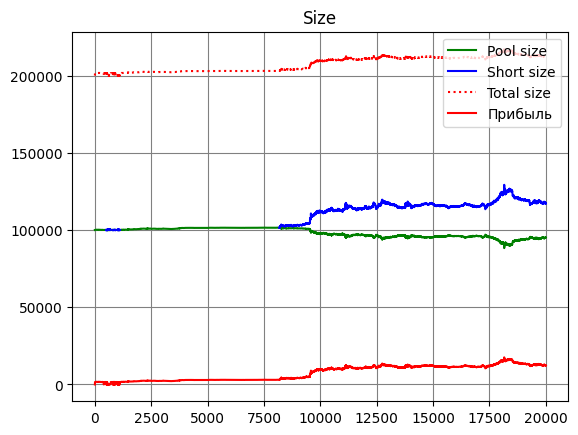

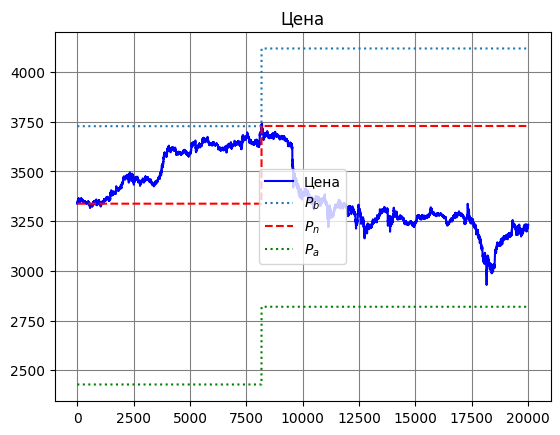

In [150]:
plt.title("Size")
plt.plot(data_out.index, data_out['pool size'], color="green", label="Pool size")
plt.plot(data_out.index, data_out['short size'], color="blue", label="Short size")
plt.plot(data_out.index, data_out['total size'], color="red", linestyle=":", label="Total size")
plt.plot(data_out.index, data_out['Прибыль'], color="red", linestyle="-", label="Прибыль")
plt.grid(True, color="gray")
plt.legend(loc="best")
plt.show()
plt.title("Цена")
plt.plot(data_in.index, data_in['close'], color="blue", label="Цена")
plt.plot(data_out.index, data_out['Pb'], linestyle=":", label="$P_b$")
plt.plot(data_out.index, data_out['pool Pn'], linestyle="--", color="red", label="$P_n$")
plt.plot(data_out.index, data_out['Pa'], linestyle=":", color="g", label="$P_a$")
# plt.axhline(y=pb, linestyle="--", label="$P_b$")
# plt.axhline(y=pool.pn, linestyle="--", color="g", label="$P_n$")
# plt.axhline(y=pa, linestyle="--", color="red", label="$P_a$")
plt.grid(True, color="gray")
plt.legend(loc="best")
plt.show()

In [147]:
data_out

,time,price,Pa,Pb,pool Pn,pool size,short size,total size,Прибыль
0,1.735690e+15,3337.99,2287.99,3787.99,3337.99,100000.000000,100000.0,200000.0,0.0
1,1.735690e+15,3338.86,2287.99,3787.99,3337.99,100006.836409,None,200006.836409,6.836409
2,1.735690e+15,3342.32,2287.99,3787.99,3337.99,100033.880950,None,200033.88095,33.88095
3,1.735690e+15,3339.98,2287.99,3787.99,3337.99,100015.615882,None,200015.615882,15.615882
4,1.735690e+15,3340.26,2287.99,3787.99,3337.99,100017.806985,None,200017.806985,17.806985
...,...,...,...,...,...,...,...,...,...
19995,1.736889e+15,3225.77,2287.99,3787.99,3337.99,98994.082428,103463.669139,202457.751567,2457.751567
19996,1.736889e+15,3228.81,2287.99,3787.99,3337.99,99024.632812,103366.255679,202390.888491,2390.888491
19997,1.736889e+15,3230.99,2287.99,3787.99,3337.99,99046.425629,103296.512834,202342.938463,2342.938463
19998,1.736889e+15,3231.65,2287.99,3787.99,3337.99,99053.004526,103275.416583,202328.421109,2328.421109
